# Initialization

In [98]:
import pandas as pd
epoch_in_minutes = 5
solver_max_timeout_in_seconds = 60 * 5
selected_date = pd.to_datetime("2022-06-01").date()
location = "California"

## Operation Pool and Job Pool Generation
- Only run once

For running toy examples

In [2]:
import random
def generate_jobs_info(num_jobs):
    short_period, medium_period, long_period = 1, 5, 50 # processing duration in epochs
    jobs_pool = [  # task = (machine_id, processing_epoch_numbers)
        [  # Job 0
            [(0, short_period), (1, short_period), (2, short_period)],  # task 0
            [(0, short_period), (1, short_period), (2, short_period)],  # task 1
        ],
        [  # Job 1
            [(0, short_period), (1, short_period), (2, short_period)],  # task 0
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 1
        ],
        [  # Job 2
            [(0, short_period), (1, short_period), (2, short_period)],  # task 0
            [(0, long_period), (1, long_period), (2, long_period)],  # task 1
        ],
        [  # Job 3
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 0
            [(0, short_period), (1, short_period), (2, short_period)],  # task 1
        ],
        [  # Job 4
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 0
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 1
        ],
        [  # Job 5
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 0
            [(0, long_period), (1, long_period), (2, long_period)],  # task 1
        ],
        [  # Job 6
            [(0, long_period), (1, long_period), (2, long_period)],  # task 0
            [(0, short_period), (1, short_period), (2, short_period)],  # task 1
        ],
        [  # Job 7
            [(0, long_period), (1, long_period), (2, long_period)],  # task 0
            [(0, medium_period), (1, medium_period), (2, medium_period)],  # task 1
        ],
        [  # Job 8
            [(0, long_period), (1, long_period), (2, long_period)],  # task 0
            [(0, long_period), (1, long_period), (2, long_period)],  # task 1
        ],
    ]
    # jobs_data = [jobs_pool[0], jobs_pool[4], jobs_pool[8]] #stats.txt
    jobs_data = [jobs_pool[8], jobs_pool[4], jobs_pool[0]] #stats2.txt
    return jobs_data

For running actual experiments

3.0758


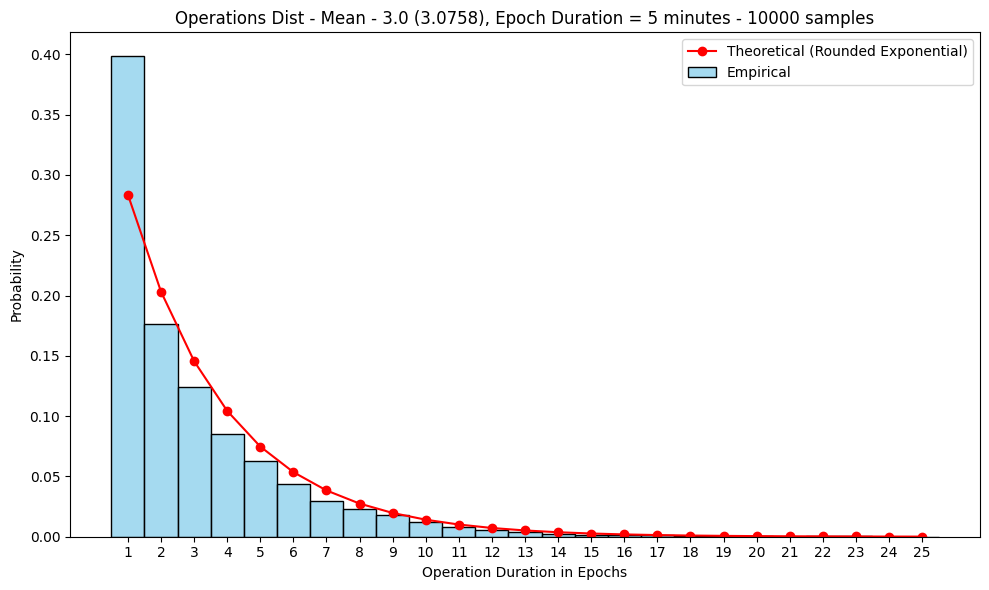

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import expon

def generate_rounded_exponential_samples(N, mean=1.0, seed=None):
    """
    Generate N samples from an Exponential distribution with given mean,
    round to nearest integer, and enforce minimum value of 1.
    """
    if seed is not None:
        np.random.seed(seed)
    durations = np.random.exponential(scale=mean, size=N)
    rounded = np.round(durations).astype(int)
    rounded[rounded < 1] = 1  # Ensure min is 1
    return rounded

def plot_empirical_vs_theoretical(samples, mean=1.0):
    """
    Plot the empirical distribution of the samples alongside the theoretical
    probabilities of the rounded exponential distribution.
    """
    max_val = samples.max()
    x_vals = np.arange(1, max_val + 1)
    
    # Theoretical probabilities for rounded exponential
    probs = expon.cdf(x_vals + 0.5, scale=mean) - expon.cdf(x_vals - 0.5, scale=mean)
    probs = probs / probs.sum()  # Normalize (in case we truncated tail)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.histplot(samples, bins=np.arange(1, max_val + 2) - 0.5, stat="probability", kde=False, color="skyblue", label="Empirical")
    plt.plot(x_vals, probs, 'o-', color="red", label="Theoretical (Rounded Exponential)")
    plt.title(f"Operations Dist - Mean - {mean} ({np.average(samples)}), Epoch Duration = {epoch_in_minutes} minutes - {len(samples)} samples")
    plt.xlabel("Operation Duration in Epochs")
    plt.ylabel("Probability")
    plt.xticks(x_vals)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Run the whole process ---
N = 10000
mean = 3.0
operarion_samples = generate_rounded_exponential_samples(N, mean=mean, seed=42)
print(np.average(operarion_samples))
plot_empirical_vs_theoretical(operarion_samples, mean=mean)

saving the operation duration

In [ ]:
df_operations = pd.DataFrame({
        "OperationIndex": np.arange(len(operarion_samples)),
        "OperationDuration": operarion_samples
    })
df_operations.to_csv(f"../Data/OperationPool/OperationsDuration_Mean={int(mean)}_Epoch={epoch_in_minutes}.csv", index=False)

creating the job pool

In [ ]:
import pandas as pd
import numpy as np
import json

global_seed = 42
rng = np.random.default_rng(global_seed)

df_operations = pd.read_csv(f"../Data/OperationsDuration_Mean={int(mean)}_Epoch={epoch_in_minutes}.csv")

# Parameters
num_jobs_in_pool = 1000
num_operations_per_job = 3  # You can vary this as needed

# Create job dictionaries
jobs = {}
for job_index in range(num_jobs_in_pool):
    sampled = df_operations.sample(n=num_operations_per_job, replace=True, random_state=global_seed + job_index)
    jobs[job_index] = {
        "operations_index": sampled["OperationIndex"].tolist(),
        "operations_duration": sampled["OperationDuration"].tolist()
    }

# Save to JSON
with open(f"../Data/JobPool/JobPool_{num_operations_per_job}Ops_MeanOpDur={int(mean)}_Epoch={epoch_in_minutes}.json", "w") as f:
    json.dump(jobs, f, indent=2)

## Sampling from Job Pool

In [89]:
import json
import random

def generate_machine_operation_schedule(job_dict, num_jobs, num_machines, seed=42):
    """
    Sample num_jobs jobs from job_dict and generate a nested list of machine-operation tuples.
    Each job is represented as a list (l1) of operations, where each operation is a list (l2)
    of tuples (machineID, operation_duration), one for each machine.
    """
    # random.seed(seed)
    
    # Sample job keys without replacement
    all_job_ids = list(job_dict.keys())
    selected_job_ids = random.sample(all_job_ids, num_jobs)
    print(selected_job_ids)

    job_schedule = []
    for job_id in selected_job_ids:
        operations = []
        durations = job_dict[job_id]["operations_duration"]
        for duration in durations:
            machine_ops = [(machine_id, duration) for machine_id in range(num_machines)]
            operations.append(machine_ops)  # l2
        job_schedule.append(operations)  # l1
    
    return job_schedule, selected_job_ids

## Carbon Intensity

In [ ]:
# Example CI
CI = [10, 20, 15, 25, 5, 10, 20, 30, 25, 15, 10, 5, 5, 10, 20,
      10, 20, 15, 25, 5, 10, 20, 30, 25, 15, 10, 5, 5, 10, 20,
      10, 20, 15, 25, 5, 10, 20, 30, 25, 15, 10, 5, 5, 10, 20,
      10, 20, 15, 25, 5, 10, 20, 30, 25, 15, 10, 5, 5, 10, 20]  # length must be ≥ horizon

In [70]:
import pandas as pd
carbon_trace = {}
carbon_trace_spec_day = {}
carbon_trace_spec_day_per_epoch = {}
carbon_trace[location] = pd.read_csv(f"../CarbonTrace/US-CAL-CISO.csv")[['datetime', 'carbon_intensity_avg']]
carbon_trace[location]['datetime'] = pd.to_datetime(carbon_trace["California"]['datetime'])

In [71]:
import pandas as pd
next_date = selected_date + pd.Timedelta(days=1)
date_windows = [selected_date]
for extra_day in range(7): # one week of intensity starting from selected date 
    next_date = selected_date + pd.Timedelta(days=extra_day)
    date_windows.append(next_date)
mask = carbon_trace[location]["datetime"].dt.date.isin(date_windows)
carbon_trace_spec_day[location] = carbon_trace[location][mask].copy()
carbon_trace_spec_day[location]["Hour"] = carbon_trace[location]["datetime"].dt.hour

In [72]:
print(len(carbon_trace_spec_day[location]))
carbon_trace_spec_day[location]

168


,datetime,carbon_intensity_avg,Hour
21168,2022-06-01 00:00:00+00:00,164.58,0
21169,2022-06-01 01:00:00+00:00,207.90,1
21170,2022-06-01 02:00:00+00:00,262.44,2
21171,2022-06-01 03:00:00+00:00,280.47,3
21172,2022-06-01 04:00:00+00:00,278.63,4
...,...,...,...
21331,2022-06-07 19:00:00+00:00,134.53,19
21332,2022-06-07 20:00:00+00:00,143.90,20
21333,2022-06-07 21:00:00+00:00,156.42,21
21334,2022-06-07 22:00:00+00:00,166.36,22


In [73]:
carbon_trace_spec_day_per_epoch[location] = []
epoch_num_in_one_hour = 60 // epoch_in_minutes
intensities = carbon_trace_spec_day[location]['carbon_intensity_avg'].tolist()
for intensity in intensities:
    for i in range(epoch_num_in_one_hour):
        carbon_trace_spec_day_per_epoch[location].append(int(round(intensity)))

In [74]:
carbon_trace_spec_day_per_epoch[location][:5]

[165, 165, 165, 165, 165]

In [75]:
len(carbon_trace_spec_day_per_epoch[location])

2016

# Experimental Setup

In [91]:
# jobs_data = generate_jobs_info(num_jobs=3) # for running toy example - also change the num_machines to 3
# num_jobs = len(jobs_data)
# # Server Info
# num_machines = 3

num_jobs = 3
num_machines = 3
num_operations_per_job = 3
mean_duration_per_op_in_epoch = 3
with open(f"../Data/JobPool/JobPool_{num_operations_per_job}Ops_MeanOpDur={mean_duration_per_op_in_epoch}_Epoch=5.json", "r") as f:
    job_dict = json.load(f)
jobs_data, job_ids = generate_machine_operation_schedule(job_dict, num_jobs = num_jobs, num_machines = num_machines)

['228', '142', '754']


In [92]:
jobs_data

[[[(0, 6), (1, 6), (2, 6)],
  [(0, 2), (1, 2), (2, 2)],
  [(0, 6), (1, 6), (2, 6)]],
 [[(0, 1), (1, 1), (2, 1)],
  [(0, 1), (1, 1), (2, 1)],
  [(0, 1), (1, 1), (2, 1)]],
 [[(0, 1), (1, 1), (2, 1)],
  [(0, 4), (1, 4), (2, 4)],
  [(0, 3), (1, 3), (2, 3)]]]

In [67]:
jobs_arrival_epoch = sorted([random.randrange(0, 24 * 60 // epoch_in_minutes) for _ in range(num_jobs)])
jobs_arrival_epoch = [0 for _ in range(num_jobs)]

In [64]:
power = 1 # machines are homogeneous
initial_horizon = 24 * 60 // epoch_in_minutes # 1 day - This is the maximum slack

# Makespan minimization

In [93]:
from ortools.sat.python import cp_model

def flexible_jobshop():
    print(f"Arrival epochs = {jobs_arrival_epoch}")
    model = cp_model.CpModel()

    all_tasks = {}
    all_machines = [[] for _ in range(num_machines)]
    # Create variables
    for job_id, job in enumerate(jobs_data):
        for task_id, alternatives in enumerate(job):
            for m_id, duration in alternatives:
                suffix = f'_{job_id}_{task_id}_{m_id}'
                start = model.NewIntVar(0, initial_horizon, 'start' + suffix)
                end = model.NewIntVar(0, initial_horizon, 'end' + suffix)
                presence = model.NewBoolVar('presence' + suffix)
                interval = model.NewOptionalIntervalVar(start, duration, end, presence, 'interval' + suffix)

                all_tasks[(job_id, task_id, m_id)] = (start, end, interval, presence)
                all_machines[m_id].append((start, duration, interval))

    # Add constraints
    for job_id, job in enumerate(jobs_data):
        for task_id, alternatives in enumerate(job):
            # Only one machine must be selected for each operation
            presences = [all_tasks[(job_id, task_id, m_id)][3] for m_id, _ in alternatives]
            model.AddExactlyOne(presences)

            # Precedence constraints between operations
            if task_id > 0:
                prev_alts = jobs_data[job_id][task_id - 1]
                curr_alts = alternatives
                for prev_m_id, _ in prev_alts:
                    for curr_m_id, _ in curr_alts:
                        prev_end = all_tasks[(job_id, task_id - 1, prev_m_id)][1]
                        curr_start = all_tasks[(job_id, task_id, curr_m_id)][0]
                        prev_presence = all_tasks[(job_id, task_id - 1, prev_m_id)][3]
                        curr_presence = all_tasks[(job_id, task_id, curr_m_id)][3]
                        model.Add(curr_start >= prev_end).OnlyEnforceIf([prev_presence, curr_presence])
            # first task's start time must be after arrival time
            if task_id == 0:
                curr_alts = alternatives
                for curr_m_id, _ in curr_alts:
                    curr_presence = all_tasks[(job_id, task_id, curr_m_id)][3]
                    curr_start = all_tasks[(job_id, task_id, curr_m_id)][0]
                    model.Add(curr_start >= jobs_arrival_epoch[job_id]).OnlyEnforceIf(curr_presence)
            
            

    # Machine capacity constraints: no overlapping intervals
    for machine_id in range(num_machines):
        machine_tasks = all_machines[machine_id]
        model.AddNoOverlap([interval for _, _, interval in machine_tasks]) # For every pair of intervals in the list, the solver ensures that if both are present, then their execution windows do not overlap

    # Objective: minimize makespan (latest end time)
    all_ends = [end for (_, end, _, _) in all_tasks.values()]
    makespan = model.NewIntVar(0, initial_horizon, 'makespan')
    model.AddMaxEquality(makespan, all_ends)
    model.Minimize(makespan)

    # Solve model
    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    # Output solution
    if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        total_carbon_consumption = 0
        print(f'Minimized makespan: {solver.Value(makespan)}')
        for (j, t, m), (start, end, interval, presence) in all_tasks.items():
            if solver.Value(presence):
                print(f'Job {j}, Task {t} on Machine {m} → Start: {solver.Value(start)}, End: {solver.Value(end)}')
                total_carbon_consumption += sum(carbon_trace_spec_day_per_epoch[location][solver.Value(start):solver.Value(end)]) * (epoch_in_minutes / 60)
        print(f"✅ Total carbon emitted: {total_carbon_consumption:.2f} g")
        return solver.Value(makespan)
    else:
        print("No solution found.")
        return None

# Run the example
global_minimum_makespan = flexible_jobshop()

Arrival epochs = [0, 0, 0]
Minimized makespan: 14
Job 0, Task 0 on Machine 1 → Start: 0, End: 6
Job 0, Task 1 on Machine 2 → Start: 6, End: 8
Job 0, Task 2 on Machine 1 → Start: 8, End: 14
Job 1, Task 0 on Machine 0 → Start: 5, End: 6
Job 1, Task 1 on Machine 2 → Start: 8, End: 9
Job 1, Task 2 on Machine 0 → Start: 9, End: 10
Job 2, Task 0 on Machine 0 → Start: 0, End: 1
Job 2, Task 1 on Machine 0 → Start: 1, End: 5
Job 2, Task 2 on Machine 0 → Start: 6, End: 9
✅ Total carbon emitted: 350.92 g


In [76]:
jobs_arrival_epoch

[0, 0, 0]

# Carbon consumption minimization

In [96]:
import math
slack_coeff = 10
max_allowed_makespan = int(math.ceil(slack_coeff * global_minimum_makespan)) # in epoch
makespan_activated = True

In [99]:
from ortools.sat.python import cp_model

def flexible_jobshop():
    model = cp_model.CpModel()
    if makespan_activated:
        horizon = max_allowed_makespan
        print(f"horizon = {horizon} -> {slack_coeff} x minimum makespan")
    else:
        horizon = initial_horizon
        print(f"horizon = {horizon} - No limit!")
    print(f"Arrival epochs = {jobs_arrival_epoch}")
    all_tasks = {}
    all_machines = [[] for _ in range(num_machines)]

    # Create variables
    for job_id, job in enumerate(jobs_data):
        for task_id, alternatives in enumerate(job):
            for m_id, duration in alternatives:
                suffix = f'_{job_id}_{task_id}_{m_id}'
                start = model.NewIntVar(0, horizon, 'start' + suffix)
                end = model.NewIntVar(0, horizon, 'end' + suffix)
                presence = model.NewBoolVar('presence' + suffix)
                interval = model.NewOptionalIntervalVar(start, duration, end, presence, 'interval' + suffix)

                all_tasks[(job_id, task_id, m_id)] = (start, end, interval, presence)
                # all_machines[m_id].append((start, duration, interval))
                all_machines[m_id].append((start, duration, interval, presence))

    # Add constraints
    for job_id, job in enumerate(jobs_data):
        for task_id, alternatives in enumerate(job):
            # Only one machine must be selected for each operation
            presences = [all_tasks[(job_id, task_id, m_id)][3] for m_id, _ in alternatives]
            model.AddExactlyOne(presences)

            # Precedence constraints between operations
            if task_id > 0:
                prev_alts = jobs_data[job_id][task_id - 1]
                curr_alts = alternatives
                for prev_m_id, _ in prev_alts:
                    for curr_m_id, _ in curr_alts:
                        prev_end = all_tasks[(job_id, task_id - 1, prev_m_id)][1]
                        curr_start = all_tasks[(job_id, task_id, curr_m_id)][0]
                        prev_presence = all_tasks[(job_id, task_id - 1, prev_m_id)][3]
                        curr_presence = all_tasks[(job_id, task_id, curr_m_id)][3]
                        model.Add(curr_start >= prev_end).OnlyEnforceIf([prev_presence, curr_presence])
            # first task's start time must be after arrival epoch
            if task_id == 0:
                curr_alts = alternatives
                for curr_m_id, _ in curr_alts:
                    curr_presence = all_tasks[(job_id, task_id, curr_m_id)][3]
                    curr_start = all_tasks[(job_id, task_id, curr_m_id)][0]
                    model.Add(curr_start >= jobs_arrival_epoch[job_id]).OnlyEnforceIf(curr_presence)
            
            

    # Machine capacity constraints: no overlapping intervals
    for machine_id in range(num_machines):
        machine_tasks = all_machines[machine_id]
        model.AddNoOverlap([interval for _, _, interval, _ in machine_tasks]) # For every pair of intervals in the list, the solver ensures that if both are present, then their execution windows do not overlap

    # Limiting makespan by an upper-bound
    if makespan_activated:
        all_ends = [end for (_, end, _, _) in all_tasks.values()]
        makespan = model.NewIntVar(0, horizon, 'makespan')
        model.AddMaxEquality(makespan, all_ends)
        model.Add(makespan <= max_allowed_makespan)
    
    
    # Carbon-aware objective
    total_carbon_terms = []
    active_vars = []
    b_vars = []
    for t in range(horizon):
        active_vars.append([])
        for m in range(num_machines):
            active = model.NewBoolVar(f'active_{t}_{m}')
            active_vars[t].append(active)
            relevant_presences = []
            for (start, dur, interval, presence) in all_machines[m]:
                b = model.NewBoolVar(f'running_{t}_{m}') # b[t][m] = True when a task is running on machine m and the time t is within the [start, end] of the task                
                in_window1 = model.NewBoolVar('')
                in_window2 = model.NewBoolVar('')
                model.Add(start <= t).OnlyEnforceIf(in_window1)
                model.Add(start > t).OnlyEnforceIf(in_window1.Not())
                model.Add(t < start + dur).OnlyEnforceIf(in_window2)
                model.Add(t >= start + dur).OnlyEnforceIf(in_window2.Not())
                model.AddImplication(b, in_window1)
                model.AddImplication(b, in_window2)
                model.AddImplication(b, presence)
                model.AddBoolOr(in_window1.Not(), in_window2.Not(), presence.Not(), b)
                relevant_presences.append(b)
            b_vars.append(relevant_presences)
            
            model.AddMaxEquality(active, relevant_presences) # if one of the b s is 1 then active[t][m] = 1

            # Compute carbon emission at this time step
            # carbon_term = model.NewIntVar(0, carbon_trace_spec_day_per_epoch[location][t] * power[m], f'carbon_{t}_{m}')
            # model.AddMultiplicationEquality(carbon_term, [active, carbon_trace_spec_day_per_epoch[location][t] * power[m]])
            carbon_value = carbon_trace_spec_day_per_epoch[location][t] * power
            carbon_term = model.NewIntVar(0, carbon_value, f'carbon_{t}_{m}')
            model.Add(carbon_term == carbon_value).OnlyEnforceIf(active)
            model.Add(carbon_term == 0).OnlyEnforceIf(active.Not())
            total_carbon_terms.append(carbon_term)

    total_carbon = model.NewIntVar(0, 1000000, 'total_carbon')
    model.Add(total_carbon == sum(total_carbon_terms))
    model.Minimize(total_carbon)

    # Solve model
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = solver_max_timeout_in_seconds
    status = solver.Solve(model)

    # Output solution
    if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        total_carbon_consumption = solver.Value(total_carbon) * (epoch_in_minutes / 60)
        if makespan_activated:
            print(f"✅ Total carbon emitted: {total_carbon_consumption:.2f} g with maximum allowed makespan = {max_allowed_makespan}")
        else:
            print(f"✅ Total carbon emitted: {total_carbon_consumption:.2f} g with 1 days limit")
        if status == cp_model.OPTIMAL:
            print(f"✅ Solution is also optimal!")
        for (j, t, m), (start, end, _, presence) in all_tasks.items():
            if solver.Value(presence):
                print(f'Job {j}, Task {t} on Machine {m} → Start: {solver.Value(start)}, End: {solver.Value(end)}')
    elif status == cp_model.INFEASIBLE:
        print("❌ Problem is infeasible.")
    else:
        print("❓ Solver stopped (possibly due to timeout) with status:", status)

# Run the example
flexible_jobshop()

horizon = 140 -> 10 x minimum makespan
Arrival epochs = [0, 0, 0]
✅ Total carbon emitted: 350.92 g with maximum allowed makespan = 140
Job 0, Task 0 on Machine 2 → Start: 0, End: 6
Job 0, Task 1 on Machine 2 → Start: 6, End: 8
Job 0, Task 2 on Machine 2 → Start: 8, End: 14
Job 1, Task 0 on Machine 1 → Start: 0, End: 1
Job 1, Task 1 on Machine 1 → Start: 1, End: 2
Job 1, Task 2 on Machine 1 → Start: 2, End: 3
Job 2, Task 0 on Machine 0 → Start: 0, End: 1
Job 2, Task 1 on Machine 0 → Start: 1, End: 5
Job 2, Task 2 on Machine 0 → Start: 5, End: 8


In [158]:
consumption = (
    sum(carbon_trace_spec_day_per_epoch[location][10:60]) +
    sum(carbon_trace_spec_day_per_epoch[location][60:110]) +
    sum(carbon_trace_spec_day_per_epoch[location][185:190]) +
    sum(carbon_trace_spec_day_per_epoch[location][190:195]) +
    sum(carbon_trace_spec_day_per_epoch[location][267:268]) +
    sum(carbon_trace_spec_day_per_epoch[location][268:269])
)
print(consumption)
print(consumption * (epoch_in_minutes / 60) )

28291
2357.583333333333
